#MLR_Assignment No.3

**Train and save the model**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/employee_salary_dataset.csv")

# Convert Education_Level (categorical) to float values
education_map = {
    'High School': 1.0,
    'Bachelor': 2.0,
    'Master': 3.0,
    'PhD': 4.0
}
df['Education_Level'] = df['Education_Level'].map(education_map).astype(float)


In [ ]:
df.shape

(50, 3)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience_Years  50 non-null     int64  
 1   Education_Level   50 non-null     float64
 2   Monthly_Salary    50 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.3 KB


In [ ]:
df.head()

,Experience_Years,Education_Level,Monthly_Salary
0,15,3.0,111416
1,7,2.0,95271
2,12,1.0,69064
3,8,4.0,95091
4,15,3.0,132450


In [ ]:
df.describe()

,Experience_Years,Education_Level,Monthly_Salary
count,50.000000,50.000000,50.0000
mean,9.900000,2.540000,82288.8000
std,5.349995,1.073046,33521.4379
min,1.000000,1.000000,28420.0000
25%,5.250000,2.000000,59424.0000
50%,10.000000,3.000000,73890.5000
75%,14.750000,3.000000,107219.0000
max,19.000000,4.000000,149123.0000


In [ ]:
#Define features (X) and target (y)
X = df[['Experience_Years', 'Education_Level']]   # independent variables
y = df['Monthly_Salary']   # dependent variable


In [ ]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#Predictions
y_pred = model.predict(X_test)

In [ ]:
#Evaluation
print("Coefficients (slopes):", model.coef_)
print("Intercept:", model.intercept_)
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Coefficients (slopes): [ 548.27207092 -248.51804036]
Intercept: 80940.07963891076
Mean Squared Error (MSE): 1491836239.9462967
R² Score: -0.26529476391226625


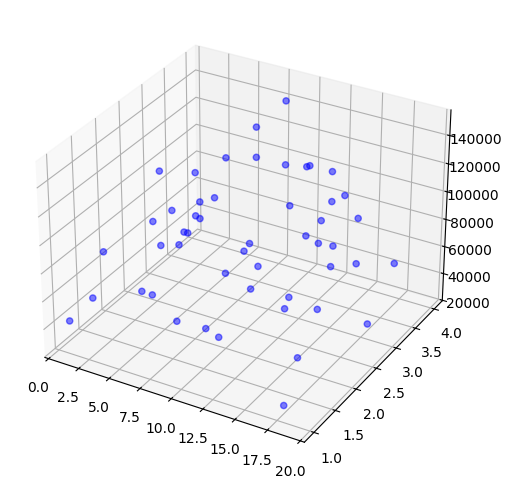

In [ ]:
#Visualisation (3D Scatter + Regression Plane)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X['Experience_Years'], X['Education_Level'], y, c='blue', marker='o', alpha=0.5, label="Actual")


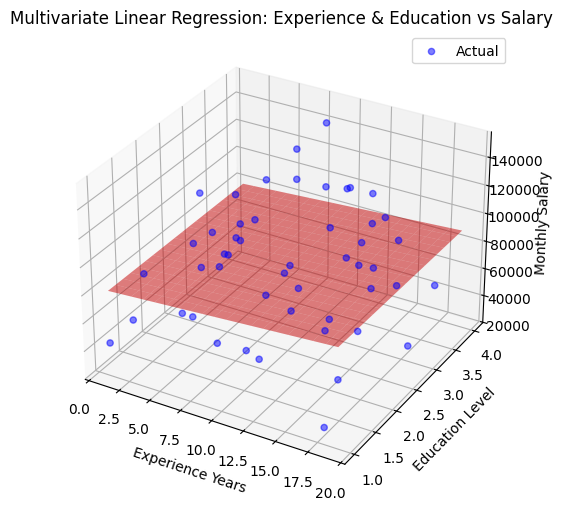

In [ ]:
#Visualisation (3D Scatter + Regression Plane)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X['Experience_Years'], X['Education_Level'], y, c='blue', marker='o', alpha=0.5, label="Actual")

# Create meshgrid for regression plane
experience_range = np.linspace(X['Experience_Years'].min(), X['Experience_Years'].max(), 20)
education_range = np.linspace(X['Education_Level'].min(), X['Education_Level'].max(), 20)
experience_grid, education_grid = np.meshgrid(experience_range, education_range)
salary_pred = model.intercept_ + model.coef_[0]*experience_grid + model.coef_[1]*education_grid

ax.plot_surface(experience_grid, education_grid, salary_pred, color='red', alpha=0.5)

ax.set_xlabel('Experience Years')
ax.set_ylabel('Education Level')
ax.set_zlabel('Monthly Salary')
ax.set_title("Multivariate Linear Regression: Experience & Education vs Salary")
plt.legend()
plt.show()


In [ ]:
#Prediction for a new employee
new_employee = np.array([[8.0, 3.0]])  # example: 8 years experience, Master
predicted_salary = model.predict(new_employee)
print("Predicted Monthly Salary:", predicted_salary[0])


Predicted Monthly Salary: 84580.70208519828


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pickle

In [ ]:
pickle.dump(model,open('MLRModel.pkl','wb'))


**Flask Code**

In [ ]:
from flask import Flask, render_template, request
import pickle
import numpy as np

app = Flask(__name__)

# Load the trained Multiple Linear Regression model
model = pickle.load(open("MLRModel.pkl", "rb"))


@app.route('/')
def home():
    return render_template("index.html")


@app.route('/predict', methods=['POST'])
def predict():

    # Read inputs from the HTML form
    experience = float(request.form['experience'])
    education = float(request.form['education'])

    # Predict monthly salary
    prediction = model.predict(np.array([[experience, education]]))

    return render_template(
        "index.html",
        prediction_text=f"Predicted Monthly Salary : {prediction[0]:.2f}"
    )


if __name__ == "__main__":
    app.run(debug=True)


**HTML Code**

In [ ]:
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Employee Salary Predictor</title>

    <style>

        *{
            margin:0;
            padding:0;
            box-sizing:border-box;
            font-family:Arial, Helvetica, sans-serif;
        }

        body{

            background:#f4f7fc;
            display:flex;
            justify-content:center;
            align-items:center;
            height:100vh;

        }

        .container{

            width:430px;
            background:white;
            padding:35px;
            border-radius:15px;
            box-shadow:0 10px 25px rgba(0,0,0,.2);

        }

        h1{

            text-align:center;
            color:#0d47a1;
            margin-bottom:8px;

        }

        h3{

            text-align:center;
            color:#555;
            margin-bottom:25px;

        }

        label{

            font-weight:bold;
            display:block;
            margin-top:12px;
            margin-bottom:6px;

        }

        input{

            width:100%;
            padding:12px;
            border:1px solid #ccc;
            border-radius:8px;
            font-size:16px;

        }

        button{

            width:100%;
            margin-top:25px;
            padding:12px;
            font-size:18px;
            background:#1565c0;
            color:white;
            border:none;
            border-radius:8px;
            cursor:pointer;
            transition:.3s;

        }

        button:hover{

            background:#0d47a1;

        }

        .result{

            margin-top:25px;
            background:#e8f5e9;
            color:green;
            padding:15px;
            border-radius:8px;
            text-align:center;
            font-size:20px;
            font-weight:bold;

        }

        footer{

            text-align:center;
            margin-top:20px;
            color:#777;
            font-size:13px;

        }

    </style>

</head>

<body>

<div class="container">

    <h1>Employee Salary Predictor</h1>

    <h3>Multiple Linear Regression</h3>

    <form action="/predict" method="POST">

        <label>Enter Student Experience Years</label>

        <input
            type="number"
            name="experience"
            step="0.01"
            min="0"
            max="10"
            placeholder="Example : 8.25"
            required>

        <label>Enter Education Level Score</label>

        <input
            type="number"
            name="education"
            placeholder="Example : 120"
            required>

        <button type="submit">

            Predict Package

        </button>

    </form>

    {% if prediction_text %}

    <div class="result">

        {{ prediction_text }}

    </div>

    {% endif %}

    <footer>

        Machine Learning by Dr. Sachin Balawant Takmare

    </footer>

</div>

</body>
</html>